# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
import os
from catboost import CatBoostClassifier, Pool


/home/mle-user/mle-project-sprint-4-v001/recsys_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet("tracks.parquet")
catalog_names = pd.read_parquet("catalog_names.parquet")
interactions = pd.read_parquet("interactions.parquet")

Посмотрим на то, как выглядят сами данные

In [4]:
display(tracks.head())
display(catalog_names.sample(5).head())
display(interactions.sample(5).head())

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,id,type,name
1430659,43051717,track,Sounds of the Forest
1110098,19142786,track,Waltz in F Minor Op. 70 No. 2
1539170,54152128,track,Enter the Darkness
352857,6038667,album,Si J'Avais Un Marteau
1682689,71237796,track,Нуар-роман


,user_id,track_id,track_seq,started_at
182,14492,496914,183,2022-10-19
352,1278474,58485665,353,2022-09-27
184,830350,33509648,185,2022-12-13
45,1056463,2347643,46,2022-04-04
128,689025,32484963,129,2022-02-17


# Обзор данных

Проверим данные на различные проблемы (дубликаты, пропуски)

In [5]:
# видим, что все записи айди треков числовые, для них нет дубликатов и пропусков
print(tracks['track_id'].dtypes)
print(tracks['track_id'].duplicated().sum()) 
print(tracks['track_id'].isnull().sum())

int64
0
0


In [6]:
album_ids = tracks['albums'].explode()
artist_ids = tracks['artists'].explode()
genre_id = tracks['genres'].explode()


Посмотрим, есть ли треки без исполнителя, альбома и жанра

P.s. такие треки есть и я их удаляю (ничего страшного, их не так много)

In [7]:
print(album_ids.isnull().sum())
print(artist_ids.isnull().sum())
print(genre_id.isnull().sum())

indices_to_drop = (album_ids[album_ids.isnull()].index.union(artist_ids[artist_ids.isnull()].index).union(genre_id[genre_id.isnull()].index))
tracks = tracks.drop(index=indices_to_drop)
tracks.reset_index(drop=True, inplace=True)

18
15369
3687


Теперь посмотрим на другие возможны пропуски в данных, а также пересесечение значений ID среди разных полей.

Видим, что такие пересечения есть. 

In [8]:

print(catalog_names.isnull().sum(axis=1).sum()) 
print(album_ids.isin(artist_ids).sum(), album_ids.isin(genre_id).sum(), artist_ids.isin(genre_id).sum()) 
print(catalog_names.duplicated().sum()) 

def check_object_ids(catalog_names: pd.DataFrame, type: str, ids: pd.Series):
    uniq_ids = ids.unique()
    catalog_type_ids = catalog_names.loc[catalog_names.type == type]['id'].unique()
    return list(set(uniq_ids) - set(catalog_type_ids))
    

no_genre_ids = check_object_ids(catalog_names, 'genre', genre_id)




0
65056 411 16670
0


In [9]:
display(catalog_names.loc[catalog_names.id.isin(no_genre_ids) & (catalog_names.type != 'genre')])

,id,type,name
49,126,album,Arma-goddamn-motherfuckin-geddon
51,132,album,LoveGame Remixes
52,133,album,Best Of
53,134,album,Specialty Profiles: Roy Milton
54,135,album,LoveGame
61,146,album,Zee Avi
62,148,album,In A Perfect World...
64,150,album,B Is For Bob
65,152,album,Trojan Lovers Collection
66,154,album,Stop!


Отфильтруем треки, айди которых есть в жанре, но нет в табличке с каталогом

In [10]:
filter_for_tracks_with_no_ids_in_catalog = tracks['genres'].apply(lambda x: not set(x).isdisjoint(no_genre_ids))


Посмотрим на типы данных полей в датасетах

In [11]:
display(tracks.dtypes)
display(catalog_names.dtypes)
display(interactions.dtypes)

track_id     int64
albums      object
artists     object
genres      object
dtype: object

id       int64
type    object
name    object
dtype: object

user_id                int32
track_id               int32
track_seq              int16
started_at    datetime64[ns]
dtype: object

Отфильтруем треки с парадоксальными айди (их нет в каталоге, но есть в жанре)

Затем удалим переменную с фильтром и остальные ненужные из оперативной памяти

In [12]:

tracks = tracks[~filter_for_tracks_with_no_ids_in_catalog]

In [13]:
del filter_for_tracks_with_no_ids_in_catalog

In [14]:
del indices_to_drop

In [15]:
del check_object_ids

Из большого датасета с пользовательскими взаимодействиями удалим те треки, которые отсутствуют в самом датасете с треками (для корректной работы алгоритмов контентной фильтрации)

In [16]:
interactions = interactions.loc[(interactions.track_id.isin(tracks.track_id))]



In [17]:
del no_genre_ids, album_ids, artist_ids, genre_id

# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.




Проблем выявилось относительно немного, но они есть. Во-первых, в датасете с треками есть записи с пропусками в колонках с очень важными атрибутами (альбом, исполнитель и жанр). Также есть треки, у которых есть айди в рамках жанра, но которые отсутствуют в датасете "каталог". 

В связи с вынужденным удалением некоторых треков полностью (из-за пропусков в ключевых колонках и из-за отсутсвия жанров в каталоге), из датасета взаимодействий также были удалены все упоминания о них.


Также, на мой взгляд, тип идентификаторов изменять не нужно, так как, опять же, все идентификаторы числовые (в отличии от датасета по книгам, с которым была работа во время спринта )


# === ЭТАП 2 ===

# EDA

Посмотрим на количество прослушанных треков

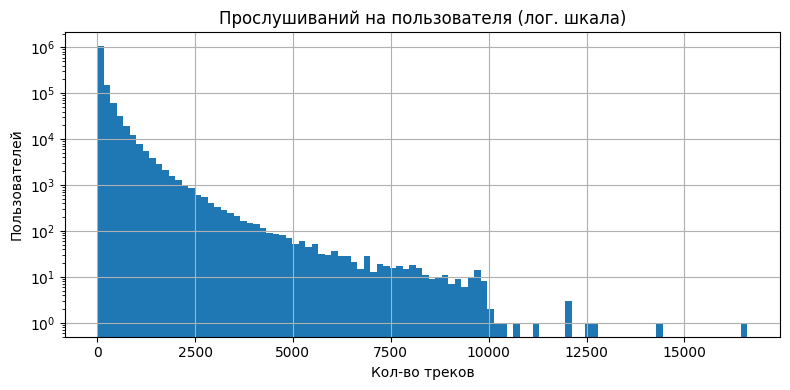

In [18]:
user_counts = interactions.groupby('user_id')['track_id'].count()
user_counts.hist(bins=100, log=True, figsize=(8, 4))
plt.title('Прослушиваний на пользователя (лог. шкала)')
plt.xlabel('Кол-во треков')
plt.ylabel('Пользователей')
plt.tight_layout()
plt.show()
plt.close()
del user_counts


Наиболее популярные треки

track_id
53404       111062
33311009    106921
178529      101924
35505245     99490
65851540     86670
24692821     86246
32947997     85886
51241318     85244
795836       85042
45499814     84748


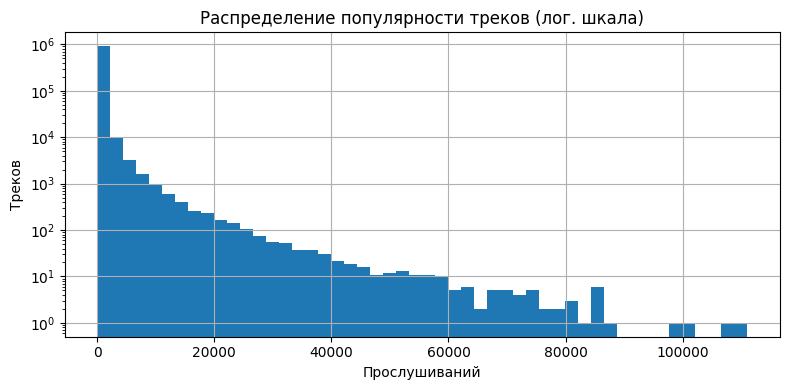

In [19]:
track_plays = interactions.groupby('track_id')['user_id'].count().sort_values(ascending=False)
print(track_plays.head(10).to_string())
track_plays.hist(bins=50, log=True, figsize=(8, 4))
plt.title('Распределение популярности треков (лог. шкала)')
plt.xlabel('Прослушиваний')
plt.ylabel('Треков')
plt.tight_layout()
plt.show()
plt.close()
del track_plays


Наиболее популярные жанры

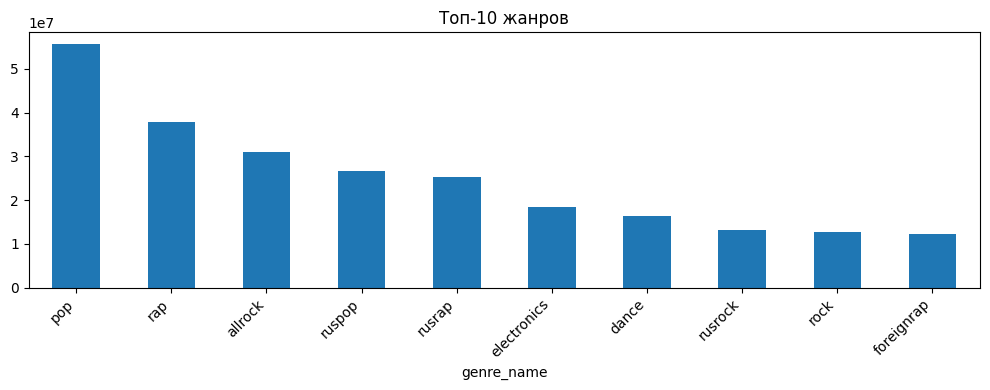

genre_name
pop            55551134
rap            37799684
allrock        31085569
ruspop         26626234
rusrap         25303695
electronics    18376062
dance          16267222
rusrock        13166147
rock           12769694
foreignrap     12194520


In [20]:
genre_map = catalog_names.loc[catalog_names['type'] == 'genre'].set_index('id')['name']
track_plays = interactions.groupby('track_id').size()

tracks_genres = tracks[['track_id', 'genres']].explode('genres').copy()
tracks_genres['plays'] = tracks_genres['track_id'].map(track_plays).fillna(0).astype(int)
tracks_genres['genre_name'] = tracks_genres['genres'].map(genre_map)

genre_popularity = (
    tracks_genres.dropna(subset=['genre_name'])
    .groupby('genre_name')['plays'].sum()
    .sort_values(ascending=False)
)
genre_popularity.head(10).plot(kind='bar', figsize=(10, 4), title='Топ-10 жанров')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()
print(genre_popularity.head(10).to_string())
del genre_map, track_plays, tracks_genres, genre_popularity


In [21]:
gc.collect()


22463

Треки, которые никто не прослушал

In [22]:
unplayed = tracks[~tracks['track_id'].isin(interactions['track_id'])]
print(f'Треков без прослушиваний: {len(unplayed)} ({len(unplayed)/len(tracks)*100:.1f}%)')
del unplayed


Треков без прослушиваний: 0 (0.0%)


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [ ]:
import os

items = tracks
events = interactions

os.makedirs('recsys/data', exist_ok=True)
os.makedirs('recsys/recommendations', exist_ok=True)

items.to_parquet('recsys/data/items.parquet')
events.to_parquet('recsys/data/events.parquet')


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [ ]:
import boto3
from botocore.exceptions import ClientError
from dotenv import load_dotenv

load_dotenv()

AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')

try:
    s3_client = boto3.client('s3', endpoint_url='https://storage.yandexcloud.net', aws_access_key_id=AWS_ACCESS_KEY_ID, aws_secret_access_key=AWS_SECRET_ACCESS_KEY)
    s3_client.upload_file("recsys/data/items.parquet", BUCKET_NAME, "recsys/data/items.parquet")
    s3_client.upload_file("recsys/data/events.parquet", BUCKET_NAME, "recsys/data/events.parquet")
    
    
except ClientError as e:
    print(f"ошибка при загрузке данных в s3: {e}")
    
except NameError as e:
    print(f"ошибка: {e}")


del items, events


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [23]:
# После этапа 2 очищаем память.
# Для этапа 3 перезапустите kernel, выполните «Инициализация»
# и начните с ячейки «Загрузка данных» (Этап 3).

for _v in ['tracks', 'catalog_names', 'interactions',
           's3_client', 'AWS_ACCESS_KEY_ID', 'AWS_SECRET_ACCESS_KEY', 'BUCKET_NAME']:
    if _v in dir():
        del globals()[_v]
gc.collect()


0

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [3]:
items = pd.read_parquet('./recsys/data/items.parquet')
events = pd.read_parquet('./recsys/data/events.parquet')


In [4]:
events.shape

(214720738, 4)

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [4]:
train_split_date = pd.Timestamp('2022-12-16')
events_train = events.query('started_at < @train_split_date').copy()
events_test = events.query('started_at >= @train_split_date').copy()



# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [ ]:
items_popularity = events_train.groupby(["track_id"], as_index=False).agg(popularity=("track_id", "count")).sort_values(by="popularity", ascending=False)
top_k = 100
top_k_items_popularity = items_popularity.head(top_k)

In [ ]:
top_k_items_popularity.head(5)

In [ ]:
top_k_items_popularity.to_parquet('./recsys/recommendations/top_popular.parquet')

# Персональные

Рассчитаем персональные рекомендации.

Закодируем треки

In [5]:
item_id_encoder = LabelEncoder().fit(items['track_id'].unique())
items['track_id_enc'] = item_id_encoder.transform(items['track_id'])

Закодируем айди треков через энкодер по трекам

In [6]:
events_train['track_id_enc'] = item_id_encoder.transform(events_train['track_id'])
events_test['track_id_enc'] = item_id_encoder.transform(events_test['track_id'])

закодируем айди пользователей через свой энкодер

In [7]:

user_id_encoder = LabelEncoder().fit(events['user_id'].unique())
events_train['user_id_enc'] = user_id_encoder.transform(events_train['user_id'])
events_test['user_id_enc'] = user_id_encoder.transform(events_test['user_id'])

In [8]:
events_train.to_parquet('recsys/data/events_train.parquet')
events_test.to_parquet('recsys/data/events_test.parquet')

In [9]:
gc.collect()

3

Создадим специальный тип матрицы для оптимизированного хранения сильно разреженной матрицы

In [ ]:
user_item_matrix_train = csr_matrix((np.ones(len(events_train)), (events_train['user_id_enc'], events_train['track_id_enc'])), dtype=np.int8)

Обучим ALS

In [ ]:
als_model = AlternatingLeastSquares(factors=40, iterations=10, regularization=0.05, random_state=0)
os.environ['OPENBLAS_NUM_THREADS'] = '1'
als_model.fit(user_item_matrix_train)




Получим рекомендации только для тех слушателей, которые есть в тестовой выборке

In [ ]:
test_user_ids = events_test['user_id'].unique()
test_user_ids_encoded = user_id_encoder.transform(
    test_user_ids[np.isin(test_user_ids, user_id_encoder.classes_)]
)

n_items = user_item_matrix_train.shape[1]
empty = csr_matrix((len(test_user_ids_encoded), n_items), dtype=np.int8)

In [ ]:
del user_item_matrix_train

gc.collect()

In [ ]:
del events
gc.collect()

In [ ]:
als_recommendations = als_model.recommend(test_user_ids_encoded,empty,filter_already_liked_items=False,N=80)
#прерываю, так как уже отработали рекомендации на предыдущих запусках ноутбука и сохранены в формат паркет

Ячейка выше выполнялась 25+ минут


Переведем рекомендации в табличный формат для корретного сбора метрик 

In [ ]:
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

In [ ]:


als_recommendations = pd.DataFrame({
    "user_id_enc": test_user_ids_encoded,
    "item_id_enc": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})

Произведем декодинг айди треков и слушателей

In [ ]:

als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)

als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

als_recommendations["user_id"] = user_id_encoder.inverse_transform(als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_id_encoder.inverse_transform(als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"])
#P.s. ошибка снизу связана с перезапуском ядра. als_recommendations успещно сохранены в Parquet

In [ ]:
als_recommendations.sort_values(by='score', ascending=False)

Получилась достаточно разреженная матриуа рекомендаций с более чем 137 миллионами строк

In [ ]:
als_recommendations.to_parquet('./recsys/recommendations/personal_als.parquet')
del als_recommendations
gc.collect()


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
train_item_ids_enc = events_train['track_id_enc'].unique() # айди треквов для рекомендаций

In [ ]:
max_similar_items = 5 #ограничим вывод похожих айтемов до 5 объектов для более быстрых вычислений (иначе ячейка выполняется вечность)
similar_items = als_model.similar_items(train_item_ids_enc, N=max_similar_items+1)

sim_item_item_ids_enc = similar_items[0]
sim_item_scores = similar_items[1]

ячейка выше выполнялась 37 минут

Преобразуем полученную матрицу похожих объектов в удобный и читаемый табличный формат. Также проведем декодинг ID треков и слушателей

In [ ]:
similar_items = pd.DataFrame({
    "item_id_enc": train_item_ids_enc,
    "sim_item_id_enc": sim_item_item_ids_enc.tolist(), 
    "score": sim_item_scores.tolist() })
similar_items = similar_items.explode(["sim_item_id_enc", "score"], ignore_index=True)

In [ ]:
similar_items["sim_item_id_enc"] = similar_items['sim_item_id_enc'].astype("int")
similar_items["score"] = similar_items["score"].astype("float")

similar_items["item_id_1"] = item_id_encoder.inverse_transform(similar_items['item_id_enc'])
similar_items["item_id_2"] = item_id_encoder.inverse_transform(similar_items['sim_item_id_enc'])
similar_items = similar_items.drop(columns=["item_id_enc", "sim_item_id_enc"])

Необходимо отфильтровать одинаковые треки в похожих айтемах. А то каждый трек будет похож на себя

In [ ]:
similar_items = similar_items.query("item_id_1 != item_id_2")

Сохраним полученные и обработанные данные в Parquet

In [ ]:
similar_items.to_parquet('./recsys/recommendations/similar.parquet')
del similar_items, als_model
gc.collect()


На данном этапе в папку recsys/recommendations сохранены три типа рекомендаций в форматах Паркет

# Построение признаков

In [6]:
del events
del items

gc.collect()

6

Построим три признака, можно больше, для ранжирующей модели.

In [13]:
events_train = pd.read_parquet('recsys/data/events_train.parquet')
events_test = pd.read_parquet('recsys/data/events_test.parquet')

In [14]:
split_date_for_labels = pd.to_datetime("2022-12-26")
events_labels = events_test[events_test['started_at'] < split_date_for_labels].copy()
events_test_2 = events_test[events_test['started_at'] >= split_date_for_labels].copy()


Первый признак: Популярность трека, выраженная в количествве прослушиваний

In [2]:

def get_tracks_popularity(df):
    return df.groupby('track_id', as_index=False).agg(popularity=('track_id', 'count')).rename(columns={'track_id': 'item_id'})

Посмотрим на долю прослушиваний определенного трека пользователем среди всех других прослушанных этим пользователем треков

In [3]:


def get_user_track_listening_stats(df):
    user_total = df.groupby('user_id', as_index=False).agg(all_listening_count=('track_id', 'count'))
    user_track_stats = df.groupby(['user_id', 'track_id'], as_index=False).agg(listening=('track_id', 'count'))
    user_track_stats = user_track_stats.merge(user_total, on='user_id', how='left')
    del user_total
    gc.collect()
    user_track_stats['listening_percent'] = (user_track_stats['listening'] / user_track_stats['all_listening_count'])
    return (user_track_stats.rename(columns={'track_id': 'item_id'}).groupby('item_id', as_index=False)['listening_percent'].mean())




Третьим признаком возьмем историю активности пользователя, выраженную в количестве лет прослушивания музыки на сервисе

In [4]:
def get_user_history_len(df) :
    return df.groupby(by='user_id', as_index=False).agg(listening_years=("started_at", lambda x: (x.max()-x.min()).days/365.25))



Сформируем признаки с помощью написанных выше функций

In [7]:
events_labels['target'] = 1

In [8]:
track_popularity = get_tracks_popularity(events_train)[['item_id', 'popularity']]

In [9]:
gc.collect()

0

In [10]:
user_track_listening_stats = get_user_track_listening_stats(events_train)[['item_id', 'listening_percent']]

In [11]:
user_history_len = get_user_history_len(events_train)[['user_id', 'listening_years']]

Подгрузим ранее сохраненный датасет с cохраненными ALS рекомендациями

In [12]:
als_recommendations = pd.read_parquet('./recsys/recommendations/personal_als.parquet')

Сформируем табличку с кандитадами на рекомендацию и заполним пропуски в целевом столбце на 0 

In [13]:
candidates = als_recommendations.merge((events_labels[['user_id', 'track_id', 'target']]).rename(columns={'track_id': 'item_id'}), how='left', on=['user_id', 'item_id'])
candidates['target'] = candidates['target'].fillna(0).astype('int')

In [14]:
candidates = candidates.merge(track_popularity, how='left', on=['item_id'])


In [15]:
candidates = candidates.merge(user_track_listening_stats, how='left', on=['item_id'])


In [16]:
candidates = candidates.merge(user_history_len, how='left', on=['user_id'])

In [20]:
candidates.to_parquet('recsys/recommendations/candidates.parquet')

In [17]:
del track_popularity, user_track_listening_stats, user_history_len

In [8]:
gc.collect()

8

In [4]:
candidates = pd.read_parquet('recsys/recommendations/candidates.parquet')

Сформируем тренировочную выборку для последующего ранжирования рекомендаций

In [5]:
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)
negatives_per_user = 4
candidates_for_train = pd.concat([candidates_to_sample.query("target == 1"), candidates_to_sample.query("target == 0").groupby("user_id").apply(lambda x: x.sample(negatives_per_user, random_state=42))])

In [6]:
del candidates_to_sample
gc.collect()

31

In [22]:
candidates_for_train

,score,user_id,item_id,target,popularity,listening_percent,listening_years
513,0.128065,10,45499814,1,78564,0.014818,0.213552
525,0.112482,10,49125069,1,42845,0.016675,0.213552
716,0.351045,12,31746480,1,33666,0.012223,0.646133
1034,0.016762,15,19606944,1,27988,0.007680,0.000000
1059,0.014939,15,17198356,1,34603,0.009245,0.000000
...,...,...,...,...,...,...,...
"(1374578, 77878618)",0.114448,1374578,178529,0,100866,0.011394,0.410678
"(1374582, 77878843)",0.120129,1374582,57284734,0,12376,0.010066,0.104038
"(1374582, 77878825)",0.140539,1374582,51452575,0,37430,0.013083,0.104038
"(1374582, 77878859)",0.107160,1374582,62352384,0,14971,0.007796,0.104038


In [ ]:
del 

In [23]:
gc.collect()

31

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

Подготовим данные для обучения ранжирующей модели CatBoostClassifier

In [7]:
features = ['score', 'popularity', 'listening_percent', 'listening_years']
target = 'target'

train_data = Pool(data=candidates_for_train[features], label=candidates_for_train[target])

In [8]:
cb_model = CatBoostClassifier(loss_function='Logloss',verbose=0,random_seed=42)

cb_model.fit(train_data)

In [16]:
als_recommendations=pd.read_parquet('recsys/recommendations/personal_als.parquet')

Cформируем список юзеров на ранжирование

In [17]:

candidates_to_rank = als_recommendations[als_recommendations["user_id"].isin(events_test_2["user_id"].drop_duplicates())]

Добавим в датасет с юзерами на ранжирование признаки, созданные в разделе "Построение признаков"

In [6]:
events_train = pd.read_parquet('recsys/data/events_train.parquet')


In [ ]:
events_test = pd.read_parquet('recsys/data/events_test.parquet')


In [7]:
track_popularity = get_tracks_popularity(events_train)[['item_id', 'popularity']]

In [8]:

gc.collect()

217

In [9]:
user_track_listening_stats = get_user_track_listening_stats(events_train)[['item_id', 'listening_percent']]

In [10]:
user_history_len = get_user_history_len(events_train)[['user_id', 'listening_years']]

In [18]:
candidates_to_rank = candidates_to_rank.merge(track_popularity, how='left', on=['item_id'])
candidates_to_rank = candidates_to_rank.merge(user_track_listening_stats, how='left', on=['item_id'])
candidates_to_rank = candidates_to_rank.merge(user_history_len, how='left', on=['user_id'])

In [19]:
candidates_to_rank.to_parquet('recsys/data/candidates_to_rank.parquet')

In [ ]:
print('hey')

In [9]:

candidates_to_rank=pd.read_parquet('recsys/data/candidates_to_rank.parquet')


In [10]:
inference_data = Pool(data=candidates_to_rank[features])
predictions = cb_model.predict_proba(inference_data)

candidates_to_rank["cb_score"] = predictions[:, 1]

candidates_to_rank = candidates_to_rank.sort_values(["user_id", "cb_score"], ascending=[True, False])
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount() + 1

max_recommendations_per_user = 100
final_recommendations = candidates_to_rank.query("rank <= @max_recommendations_per_user")

In [11]:
final_recommendations.to_parquet('./recsys/recommendations/recommendations.parquet')

In [12]:

for _v in ['als_model', 'user_item_matrix_train', 'candidates', 'candidates_to_sample', 'candidates_for_train', 'candidates_to_rank', 'inference_data','similar_items', 'als_recommendations', 'events_labels', 'events_test_2', 'train_item_ids_enc']:
    if _v in globals():
        del globals()[_v]
gc.collect()


31

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [1]:
import pandas as pd
import numpy as np
from gc import collect

In [5]:
def _topk_recs(recs_df: pd.DataFrame, k: int, score_col: str = None) -> pd.DataFrame:
    if score_col is None:
        numeric_cols = [
            c for c in recs_df.columns if c not in ('user_id', 'item_id') and pd.api.types.is_numeric_dtype(recs_df[c])
        ]
        score_col = numeric_cols[0] if numeric_cols else recs_df.columns[-1]
    return (recs_df.sort_values(['user_id', score_col], ascending=[True, False]).groupby('user_id', as_index=False).head(k)[['user_id', 'item_id']])


def process_events_recs_for_binary_metrics(events_train,events_test,recs,score_col: str = 'score',top_k: int = None):
    common_users = set(events_test['user_id']) & set(recs['user_id'])
    train_items = frozenset(events_train['item_id'])

    gt = (events_test.loc[events_test['user_id'].isin(common_users), ['user_id', 'item_id']].loc[lambda d: d['item_id'].isin(train_items)].assign(gt=True))

    if score_col not in recs.columns:
        score_col = next((c for c in recs.columns if c not in ('user_id', 'item_id') and pd.api.types.is_numeric_dtype(recs[c])), recs.columns[-1])

    pred = recs.loc[recs['user_id'].isin(common_users), ['user_id', 'item_id', score_col]].copy()
    if top_k is not None:
        pred = (pred.sort_values(['user_id', score_col], ascending=[True, False]).groupby('user_id', as_index=False).head(top_k))

    merged = gt.merge(pred, on=['user_id', 'item_id'], how='outer')
    merged['gt'] = merged['gt'].fillna(False)
    merged['pr'] = merged[score_col].notna()
    merged['tp'] = (merged['gt'] & merged['pr']).astype(np.int8)
    merged['fp'] = (~merged['gt'] & merged['pr']).astype(np.int8)
    merged['fn'] = (merged['gt'] & ~merged['pr']).astype(np.int8)
    return merged[['user_id', 'item_id', 'tp', 'fp', 'fn']]

In [6]:
def compute_recall_precision_metrics(events_recs_for_binary_metric):
    g = events_recs_for_binary_metric.groupby('user_id')[['tp', 'fp', 'fn']].sum()
    precision = (g['tp'] / (g['tp'] + g['fp'])).fillna(0).mean()
    recall = (g['tp'] / (g['tp'] + g['fn'])).fillna(0).mean()
    return precision, recall


In [8]:
def calculate_novelty(events_train,recommendations_df,k: int = 5,score_col: str = None):
    topk = _topk_recs(recommendations_df, k, score_col=score_col)
    seen = events_train[['user_id', 'item_id']].drop_duplicates().assign(_seen=True)
    topk = topk.merge(seen, on=['user_id', 'item_id'], how='left')
    topk['novel'] = topk['_seen'].isna().astype(np.int8)
    return topk.groupby('user_id')['novel'].mean().mean()

In [9]:
def calculate_coverage(events_train,recommendations_df,k: int = 5,score_col: str = None):
    topk = _topk_recs(recommendations_df, k, score_col=score_col)
    return topk['item_id'].nunique() / events_train['item_id'].nunique()

In [6]:
events_test = pd.read_parquet('recsys/data/events_test.parquet').rename(columns={'track_id': 'item_id'})

In [ ]:
events_train = pd.read_parquet('recsys/data/events_train.parquet').rename(columns={'track_id': 'item_id'})


Cyачала смотрим на рекомендации популярных треков

In [5]:
top_popular_recs = pd.read_parquet('./recsys/recommendations/top_popular.parquet').rename(columns={'track_id': 'item_id'})

In [6]:

top_recs_with_users = events_test[['user_id', 'item_id']].merge(top_popular_recs, how='left', on=['item_id'])


In [7]:
top_recs_with_users.to_parquet('./recsys/recommendations/top_recs_with_users.parquet')

In [11]:
top_recs_with_users = pd.read_parquet('./recsys/recommendations/top_recs_with_users.parquet')

In [12]:
prepared = process_events_recs_for_binary_metrics(
    events_train, events_test,
    top_recs_with_users.rename(columns={'popularity': 'score'}),
)
top_precision, top_recall = compute_recall_precision_metrics(prepared)
del prepared
collect()
top_novelty = calculate_novelty(events_train, top_recs_with_users, score_col='popularity')
top_coverage = calculate_coverage(events_train, top_recs_with_users, score_col='popularity')

Посмотрим на метрики для популярных айтемов

In [13]:
print(f"Топ популярных:  precision={top_precision:.3f}  recall={top_recall:.3f}  novelty@5={top_novelty:.3f}  coverage@5={top_coverage:.3f}")

Топ популярных:  precision=0.212  recall=0.034  novelty@5=1.000  coverage@5=0.336


In [14]:
collect()

31

Оценим персональные рекомендации для слушателей, построенные через ALS

In [15]:
als_recs = pd.read_parquet('./recsys/recommendations/personal_als.parquet')

In [17]:
prepared = process_events_recs_for_binary_metrics(events_train, events_test, als_recs)
als_precision, als_recall = compute_recall_precision_metrics(prepared)
del prepared
collect()
als_novelty = calculate_novelty(events_train, als_recs)
als_coverage = calculate_coverage(events_train, als_recs)

In [18]:
print(f"ALS:             precision={als_precision}  recall={als_recall}  novelty@5={als_novelty}  coverage@5={als_coverage}")

ALS:             precision=0.0067228479087403665  recall=0.0846277165786436  novelty@5=0.6342413670455026  coverage@5=0.0023702629597613005


## Теперь оценим ранжирующую модель

In [15]:
import pandas as pd
import numpy as np
from gc import collect

In [11]:
events_train = pd.read_parquet('recsys/data/events_train.parquet').rename(columns={'track_id': 'item_id'})
events_test = pd.read_parquet('recsys/data/events_test.parquet').rename(columns={'track_id': 'item_id'})

In [3]:
final_recs = pd.read_parquet('./recsys/recommendations/recommendations.parquet')
final_recs = final_recs[['user_id', 'item_id', 'cb_score']].rename(columns={'cb_score': 'score'})

In [12]:
prepared = process_events_recs_for_binary_metrics(events_train, events_test, final_recs)


In [13]:
fin_precision, fin_recall = compute_recall_precision_metrics(prepared)

In [ ]:
print(f"CatBoost ранжирующая модель.    precision: {fin_precision} , recall: {fin_recall}")

Catboost ранжирующая модель.    precision: 0.008846350638346644 , recall: 0.08337871351863937


In [19]:

collect()

31

In [20]:
fin_novelty = calculate_novelty(events_train, final_recs)

In [21]:
fin_coverage = calculate_coverage(events_train, final_recs)

In [22]:
print(f"CatBoost второстепенные метрики :    novelty@5={fin_novelty}  coverage@5={fin_coverage}")


CatBoost второстепенные метрики :    novelty@5=0.8333986893325092  coverage@5=0.0049947124903205325


# Загрузим все файлы и метрики в S3

In [25]:
import boto3
from botocore.exceptions import ClientError
from dotenv import load_dotenv
import os
load_dotenv()

AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
BUCKET_NAME = os.environ.get('S3_BUCKET_NAME')

In [26]:
s3_client = boto3.client('s3',endpoint_url='https://storage.yandexcloud.net',aws_access_key_id=AWS_ACCESS_KEY_ID,aws_secret_access_key=AWS_SECRET_ACCESS_KEY)
s3_client.upload_file("recsys/recommendations/personal_als.parquet",BUCKET_NAME,"recsys/recommendations/personal_als.parquet")
s3_client.upload_file("recsys/recommendations/recommendations.parquet",BUCKET_NAME,"recsys/recommendations/recommendations.parquet")
s3_client.upload_file("recsys/recommendations/similar.parquet",BUCKET_NAME,"recsys/recommendations/similar.parquet")
s3_client.upload_file("recsys/recommendations/top_popular.parquet",BUCKET_NAME,"recsys/recommendations/top_popular.parquet")
    


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

## Выводы по метрикам качества рекомендаций

### Precision / Recall
- **Топ популярных треков** демонстрирует наивысшую precision (примерно 0.212), но recall очень низкий — большинство релевантных треков видимо не попадают в рекомендации.
- **ALS и CatBoost** существенно уступают по precision (0.007–0.008), но выигрывают в recall ( примерно 0.084–0.085): коллаборативная фильтрация находит до менее очевидные, но более подходящих треки. В этом ее плюс

### Novelty@5
- **ALS** (0.629): значительная часть рекомендаций пересекается с историей прослушиваний пользователя.
- **CatBoost** (0.844): признаковая инженерия и ранжирование помогают более новым трекам попадать в рекомендации. Очевидно, что это хороший показатель как для стримингового сервиса, так и для самого слушателя

### Coverage@5
- **Топ популярных треков ** охватывает  примерно 33.6% каталогаплохой показатель для наивной стратегии рекомнедаций. 
- **ALS** рекомендует крайне узкий набор объектов (всего 0.2% каталога).
- **CatBoost** незначительно расширяет покрытие (примерно 0.7%), но проблема узкого ассортимента треков сохраняется.



В итоге можно сказать, что ранжирующая модель с CatBoost является наилучшим решением в данной ситуации, демонстрируя наивысшие показатели метрик